## Simple MultiAI Agent Architecture

In [53]:
import os
from dotenv import load_dotenv

from typing import TypedDict, Literal, List, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain.agents import create_agent
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_community.tools.tavily_search import TavilySearchResults

In [54]:
load_dotenv()

True

In [55]:
class AgentState(MessagesState):
  next_agent: str

In [56]:
# Simple tools using tool decorator
from langchain_core.tools import tool

@tool
def search_web(query: str) -> str:
  """Search information from the web"""
  tavily = TavilySearchResults(max_results=4)
  results = tavily.invoke(query)
  return str(results)

@tool 
def write_summary(content: str) -> str:
  """Write the summary of the provided content"""

  summary = f"Summary of the findings: \n\n{content}"
  return summary

In [57]:
llm = ChatGroq(
  model_name="llama-3.1-8b-instant",
  temperature=0
)

In [58]:
def researcher_agent(state: AgentState):
  """Researcher agent that researches information."""

  messages = state["messages"]

  system_message = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")

  researcher_llm = llm.bind_tools([search_web])
  response = researcher_llm.invoke([system_message] + messages)

  return {
    "messages": [response],
    "next_agent": "writer"
  }

def writer_agent(state: AgentState):
  """Writer agent that writes summary of the research"""

  messages = state["messages"]

  system_message = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")

  response = llm.invoke([system_message] + messages)

  return {
    "messages": [response],
    "next_agent": "end"
  }

In [59]:
from langgraph.prebuilt import ToolNode

# Tool Executor Node
def execute_tool_calls(state: AgentState):
  """Execute any pending tool calls"""

  messages = state["messages"]
  last_message = messages[-1]

  # Check if there are tool calls to execute
  if hasattr(last_message, "tool_calls") and last_message.tool_calls:
    # Create the tool node and execute
    tool_node = ToolNode([search_web, write_summary])
    response = tool_node.invoke(state)

    return response
  

  # If there are no tool calls to execute
  return state

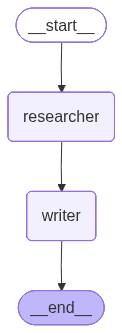

In [60]:
from langgraph.checkpoint.memory import MemorySaver

# Creating simple graph
workflow = StateGraph(MessagesState)

# Memory for the workflow
memory = MemorySaver()

# Add Nodes - 2nd component of the agentic architecture
workflow.add_node('researcher', researcher_agent)
workflow.add_node('writer', writer_agent)

# Add edges - 3rd component of the agentic architecture
workflow.set_entry_point('researcher')
workflow.add_edge('researcher', 'writer')
workflow.add_edge('writer', END)

final_workflow = workflow.compile(checkpointer=memory)

final_workflow

In [61]:
config = {"configurable": {"thread_id": 1}}
response = final_workflow.invoke({"messages": "Research about the viablity, current implementations, and security implications of Artificial Intelligence (AI) in healthcare environments."}, config)

# response = res["messages"][-1].content

In [62]:
for res in response["messages"]:
  res.pretty_print()

================================ Human Message =================================

Research about the viablity, current implementations, and security implications of Artificial Intelligence (AI) in healthcare environments.
================================== Ai Message ==================================
Tool Calls:
  search_web (xrcgp4b33)
 Call ID: xrcgp4b33
  Args:
    query: Artificial Intelligence in healthcare environments viability current implementations security implications
================================== Ai Message ==================================

 

**Summary of Findings:**

Artificial Intelligence (AI) in healthcare environments has shown significant viability, with various implementations across the globe. The primary focus areas include:

1. **Clinical Decision Support Systems (CDSSs):** AI-powered CDSSs assist healthcare professionals in making informed decisions by analyzing patient data, medical literature, and expert opinions.
2. **Predictive Analytics:** AI-drive

## Supervisor Multi AI Agent Architecture

In [63]:
from typing import TypedDict, Dict, Literal, Annotated, Any, List
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, END
import random
from datetime import datetime

In [ ]:
# Defining the state